# Введение в регрессионный анализ: основной курс
## Задачи для тренировки по итогам недели №1

*Алла Тамбовцева*

Импортируйте необходимые библиотеки и выполните задачи ниже.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

### Задача 1

Постройте, используя массив значений `x` и возможности `matplotlib`, график функции $f(x) = 5x + 10$. 

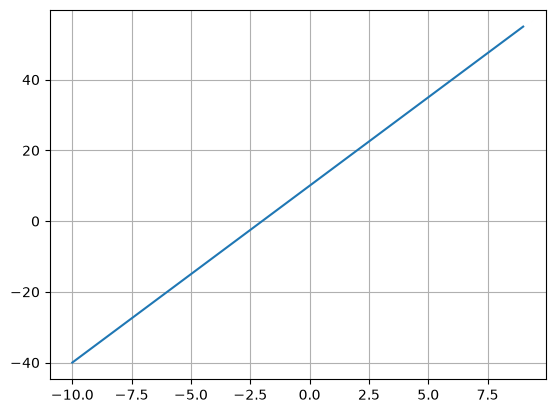

In [3]:
x = np.arange(-10, 10)

# считаем для каждого значения x значение f(x)
# создаем график и в оси добавляем точки, соединенные линией – .plot()
# добавляем сетку для удобства – .grid()

fx = 5 * x + 10
fig, ax = plt.subplots()
ax.plot(x, fx);
ax.grid();

### Задача 2

Загрузите данные из файла `employee.csv` (скачать [здесь](https://github.com/allatambov/PyReg26/blob/main/employee.csv)). Добавьте столбец `log_current_salary` с логарифмированными (натуральный логарифм) значениями заработной платы `current_salary`.

Подсказка: функция `log()` из библиотеки `numpy`.

In [5]:
df = pd.read_csv("employee.csv")

In [6]:
df["log_current_salary"] = np.log(df["current_salary"])

### Задача 3

Для дальнейшей работы нам потребуются данные по сотрудникам с ненулевым опытом работы (`years_experience`).  Оставьте в датафрейме строки, соответствующие таким сотрудникам.

In [7]:
# отфильтровываем строки и сохраняем с тем же названием
df = df[df["years_experience"] > 0]

### Задача 4

a. Постройте диаграмму рассеивания для показателей `log_current_salary` и  `years_experience`, используя методы `pandas`. 

b. Постройте диаграмму рассеивания для показателей `log_current_salary` и  `years_experience`, используя методы `matplotlib`. Измените цвет точек и добавьте подписи по горизонтальной и вертикальной оси.

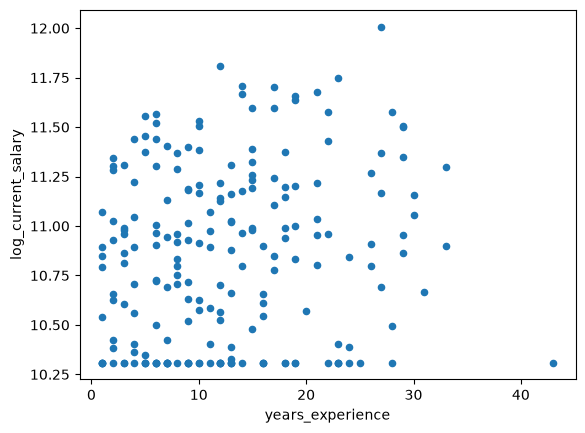

In [8]:
# a
df.plot.scatter(x = "years_experience", y = "log_current_salary");

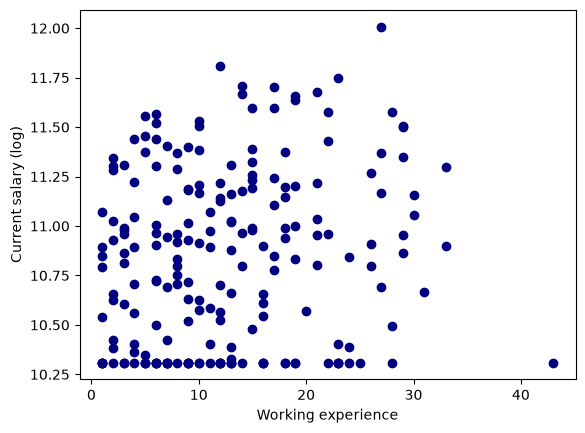

In [10]:
# b
fig, ax = plt.subplots()
ax.scatter(df["years_experience"], df["log_current_salary"], color = "navy");
ax.set_xlabel("Working experience");
ax.set_ylabel("Current salary (log)");

### Задача 5

Добавьте на полученную в пункте b) диаграмму регрессионную прямую, используя функцию `polyfit()` из `numpy` и сопутствующие функции для отрисовки графиков.

In [12]:
# на первом месте – x, на втором – y,
# функция вычисляет коэффициенты

b1, b0 = np.polyfit(df["years_experience"], df["log_current_salary"], deg = 1)
print(b1)
print(b0)

0.00867067371217849
10.73667762700931


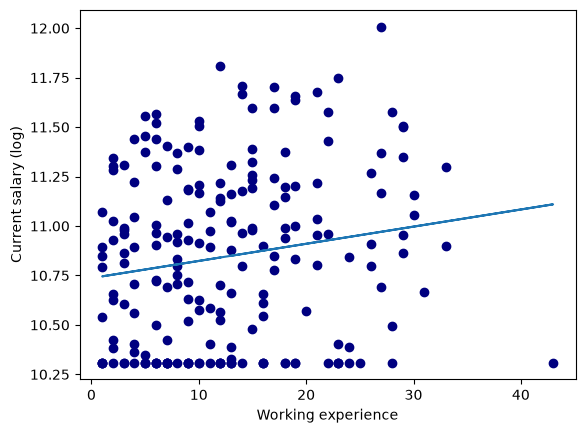

In [13]:
fig, ax = plt.subplots()
ax.scatter(df["years_experience"], df["log_current_salary"], color = "navy");

# вычисляем y = b0 + b1 * x
# добавляем линию через .plot(),
# указываем координаты точек по x и по y

ax.plot(df["years_experience"], b0 + b1 * df["years_experience"])

ax.set_xlabel("Working experience");
ax.set_ylabel("Current salary (log)");